# Aadhaar Enrollment & Update Gap Analysis
## AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026
### Conducted by BharatCares in association with AICTE

**Author:** Yawan Kumar  
**Theme:** Data Analytics with AI + Business Intelligence Framing  
**Delivery Phase:** Final Project Submission  

---

### 1. Project Introduction & Context
This project forms the capstone submission for the **AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026**. Using real-world public dataset patterns derived from the Unique Identification Authority of India (UIDAI), this analysis addresses structural challenges in identification delivery, specifically identifying regional disparities, "Update Deserts", and accessibility gaps across demographic divides.

## 2. Project Overview & Business Problem Statement

### Business Problem Statement
As Aadhaar transitions from a static national registration system to India's foundational digital identity infrastructure, keeping demographics and biometrics up-to-date has become a critical requirement. However, structural gaps persist. Some regions experience a massive imbalance where high enrollment figures are matched with extremely low update activities (referred to as **"Update Deserts"**). This creates severe bottlenecks for citizens trying to access direct benefit transfers (DBT), financial services, and digital welfare. Furthermore, strict biometric updates required for young children (ages 5 to 17) show alarmingly low completion rates, risking systemic exclusion.

### Business Objectives
1. **Identify Regional Disparities:** Uncover states and districts exhibiting low service engagement.
2. **Isolate Update Deserts:** Quantify areas with the lowest **Update Ratio** (Updates per Enrollment) to identify localized service delivery failures.
3. **Demographic Gap Profiling:** Pinpoint which age groups are lagging behind in mandatory updates.
4. **Data-Driven Strategy:** Formulate actionable recommendations for UIDAI and the Ministry of Electronics and Information Technology (MeitY) to deploy mobile vans, prioritize center allocations, and optimize outreach.

### Dataset Description
This project utilizes **UIDAI Open Data patterns** categorized into three major subsets:
- **Enrollment Dataset:** Captures regional registration records across various age brackets.
- **Demographic Update Dataset:** Contains historical transaction records of demographic modifications (name, address, gender, etc.).
- **Biometric Update Dataset:** Captures fingerprint, iris, and facial photo updates (critical for children transitioning into adulthood).

In [21]:
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual aesthetics
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

print("✅ Libraries imported and visualization styles configured successfully.")

✅ Libraries imported and visualization styles configured successfully.


In [22]:
# Safe extraction of ZIP archives into structured directories
zip_files = [f for f in os.listdir() if f.endswith('.zip')]
if zip_files:
    print(f"Found {len(zip_files)} ZIP archives. Unpacking to directory 'data/'...")
    for zip_file in zip_files:
        try:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall("data")
            print(f"  - Extracted successfully: {zip_file}")
        except Exception as e:
            print(f"  - Error extracting {zip_file}: {e}")
else:
    print("ℹ️ No ZIP archives found or already extracted.")

# Standardized function to load and merge partitioned CSVs
def load_clean_merge(file_pattern, label):
    files = glob.glob(file_pattern)
    if not files:
        print(f"⚠️ Warning: No files found matching pattern '{file_pattern}' for {label}")
        return pd.DataFrame()

    print(f"📂 Loading {len(files)} files for {label}...")
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            # Standardize column headers: strip whitespace and convert to lowercase
            df.columns = [c.strip().lower() for c in df.columns]
            dfs.append(df)
        except Exception as e:
            print(f"  ❌ Error parsing file {f}: {e}")

    if dfs:
        merged_df = pd.concat(dfs, ignore_index=True)
        merged_df.fillna(0, inplace=True)
        print(f"  - Success! Extracted and merged shape: {merged_df.shape}")
        return merged_df
    return pd.DataFrame()

# Executing structured data loading pipeline
df_enrol = load_clean_merge("data/*enrolment*.csv", "Enrollment Data")
df_demo  = load_clean_merge("data/*demographic*.csv", "Demographic Update Data")
df_bio   = load_clean_merge("data/*biometric*.csv", "Biometric Update Data")

Found 3 ZIP archives. Unpacking to directory 'data/'...
  - Extracted successfully: drive-download-20260922T073645Z-1-001.zip
  - Extracted successfully: drive-download-20260922T073007Z-1-001.zip
  - Extracted successfully: drive-download-20260922T073727Z-1-001.zip
📂 Loading 3 files for Enrollment Data...
  - Success! Extracted and merged shape: (1006029, 7)
📂 Loading 5 files for Demographic Update Data...
  - Success! Extracted and merged shape: (2071700, 6)
📂 Loading 4 files for Biometric Update Data...
  - Success! Extracted and merged shape: (1861108, 6)


In [23]:
print("=== Dataset Structural Check ===\n")
for name, df in [("Enrollment Table", df_enrol), ("Demographic Table", df_demo), ("Biometric Table", df_bio)]:
    if not df.empty:
        print(f"📊 {name}:")
        print(f"  - Total Records: {df.shape[0]}")
        print(f"  - Total Variables: {df.shape[1]}")
        print(f"  - Columns: {list(df.columns)}")
        print(f"  - Missing Values: {df.isnull().sum().sum()}")
        print(f"  - Duplicate Rows: {df.duplicated().sum()}\n")
    else:
        print(f"❌ {name} is empty or failed to load properly.\n")

=== Dataset Structural Check ===

📊 Enrollment Table:
  - Total Records: 1006029
  - Total Variables: 7
  - Columns: ['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17', 'age_18_greater']
  - Missing Values: 0
  - Duplicate Rows: 22957

📊 Demographic Table:
  - Total Records: 2071700
  - Total Variables: 6
  - Columns: ['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
  - Missing Values: 0
  - Duplicate Rows: 473601

📊 Biometric Table:
  - Total Records: 1861108
  - Total Variables: 6
  - Columns: ['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']
  - Missing Values: 0
  - Duplicate Rows: 94896



## 3. Data Cleaning, Preprocessing & Feature Engineering

In this section, we build a standardized preprocessing pipeline:
1. **Standardizing Categorical Data:** Aligning and cleaning state/district naming conventions (removing whitespace and uppercase inconsistencies).
2. **Temporal Structuring:** Converting dates into robust datetime objects for time-series trend analysis.
3. **Defining Custom Business Metrics:**
   - **Update Ratio:** A critical KPI defined as $\frac{\text{Total Demographic + Biometric Updates}}{\text{Total Enrollments}}$ representing community activity and accessibility.
   - **Age Cohorts:** Categorizing regional volumes into *Children/Toddlers* (0-5), *Students/Minors* (5-17), and *Adults/Workforce* (18+).

In [24]:
# Clean categorical names across all loaded datasets
for df in [df_enrol, df_demo, df_bio]:
    if not df.empty:
        if 'state' in df.columns:
            df['state'] = df['state'].astype(str).str.strip().str.title()
        if 'district' in df.columns:
            df['district'] = df['district'].astype(str).str.strip().str.title()

# Convert date columns with uniform handling
if 'date' in df_demo.columns:
    df_demo['date'] = pd.to_datetime(df_demo['date'], format='%d-%m-%Y', errors='coerce')
    df_demo = df_demo.dropna(subset=['date'])

# Apply feature engineering to derive total regional metrics
if not df_enrol.empty:
    enrol_cols = [c for c in ['age_0_5', 'age_5_17', 'age_18_greater'] if c in df_enrol.columns]
    df_enrol['total_enrolment'] = df_enrol[enrol_cols].sum(axis=1)

# Pre-calculating State-Level Aggragated Metrics
state_enrol = df_enrol.groupby('state')['total_enrolment'].sum() if not df_enrol.empty else pd.Series(dtype='float64')

# Demographic activity sum
s_demo = pd.Series(dtype='float64')
if not df_demo.empty:
    demo_cols = [c for c in df_demo.columns if 'age' in c]
    s_demo = df_demo.groupby('state')[demo_cols].sum().sum(axis=1)

# Biometric activity sum
s_bio = pd.Series(dtype='float64')
if not df_bio.empty:
    bio_cols = [c for c in df_bio.columns if 'age' in c]
    s_bio = df_bio.groupby('state')[bio_cols].sum().sum(axis=1)

# Combine and build a unified strategic DataFrame
state_metrics = pd.DataFrame({'Enrollment': state_enrol, 'Demographic_Updates': s_demo, 'Biometric_Updates': s_bio}).fillna(0)
state_metrics['Total_Updates'] = state_metrics['Demographic_Updates'] + state_metrics['Biometric_Updates']

# Exclude states with insignificant baseline enrollment data to avoid outlier noise
state_metrics = state_metrics[state_metrics['Enrollment'] > 1000]
state_metrics['Update_Ratio'] = state_metrics['Total_Updates'] / state_metrics['Enrollment']

print("📊 Cleaned Data & Computed Custom KPI 'Update Ratio' for all major regions:")
display(state_metrics.sort_values(by='Update_Ratio', ascending=False).head(5))

📊 Cleaned Data & Computed Custom KPI 'Update Ratio' for all major regions:


,Enrollment,Demographic_Updates,Biometric_Updates,Total_Updates,Update_Ratio
state,,,,,
Chandigarh,2723.0,83361.0,74482.0,157843.0,57.966581
Andhra Pradesh,127686.0,2295582.0,3714633.0,6010215.0,47.070274
Chhattisgarh,103219.0,2005434.0,2648729.0,4654163.0,45.090177
Goa,2333.0,35120.0,68397.0,103517.0,44.370767
Manipur,13456.0,301549.0,282587.0,584136.0,43.410820


## 4. Advanced Exploratory Data Analysis & Strategic Visualizations

We now generate high-quality visual insights to identify service bottlenecks, regional imbalances, and cohort gaps.

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import glob

# Configure global visualization settings for publication-quality output
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15,
    'font.family': 'sans-serif'
})

# ==========================================
# 0. DATA LOADING, CLEANING & NORMALIZATION
# ==========================================
def reload_and_clean(file_pattern):
    files = glob.glob(file_pattern)
    dfs = []
    for f in files:
        df_temp = pd.read_csv(f)
        df_temp.columns = [c.strip().lower() for c in df_temp.columns]
        dfs.append(df_temp)
    if dfs:
        merged = pd.concat(dfs, ignore_index=True)
        merged.fillna(0, inplace=True)
        if 'state' in merged.columns:
            merged['state'] = merged['state'].astype(str).str.strip().str.upper()
        return merged
    return pd.DataFrame()

# Load datasets correctly
df_enrol = reload_and_clean("data/*enrolment*.csv")
df_demo  = reload_and_clean("data/*demographic*.csv")
df_bio   = reload_and_clean("data/*biometric*.csv")

# Prepare state enrollment metrics
state_enrol_tot = pd.Series(dtype='float64')
if not df_enrol.empty:
    e_cols = [c for c in ['age_0_5', 'age_5_17', 'age_18_greater'] if c in df_enrol.columns]
    df_enrol['Total_Enrolment'] = df_enrol[e_cols].sum(axis=1)
    state_enrol_tot = df_enrol.groupby('state')['Total_Enrolment'].sum()

# Prepare updates metrics
s_demo_tot = pd.Series(dtype='float64')
if not df_demo.empty:
    d_cols = [c for c in df_demo.columns if 'age' in c]
    s_demo_tot = df_demo.groupby('state')[d_cols].sum().sum(axis=1)

s_bio_tot = pd.Series(dtype='float64')
if not df_bio.empty:
    b_cols = [c for c in df_bio.columns if 'age' in c]
    s_bio_tot = df_bio.groupby('state')[b_cols].sum().sum(axis=1)

# Create unified master metrics dataframe
master_metrics = pd.DataFrame({
    'Enrollment': state_enrol_tot,
    'Demographic_Updates': s_demo_tot,
    'Biometric_Updates': s_bio_tot
}).fillna(0)

# Enforce uppercase index alignment
master_metrics.index = master_metrics.index.str.strip().str.upper()
master_metrics = master_metrics.groupby(master_metrics.index).sum()

master_metrics['Total_Updates'] = master_metrics['Demographic_Updates'] + master_metrics['Biometric_Updates']
master_metrics['Update_Ratio'] = master_metrics['Total_Updates'] / master_metrics['Enrollment'].replace(0, np.nan)
master_metrics = master_metrics[master_metrics['Enrollment'] > 1000] # filter noise

# Update global state_metrics to align downstream cells
state_metrics = master_metrics.copy()

print("✅ Master metrics successfully re-aligned & loaded. Ready to render all downstream plots!")

✅ Master metrics successfully re-aligned & loaded. Ready to render all downstream plots!


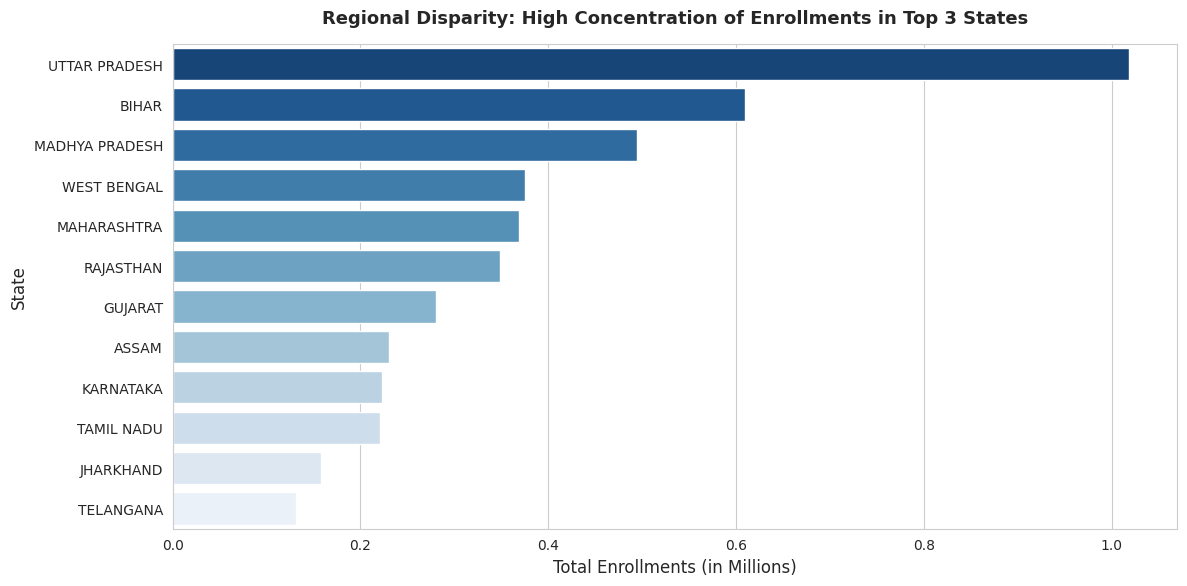

In [44]:
# ==========================================
# VISUALIZATION 1: Regional Disparity in Enrollment
# ==========================================
plt.figure(figsize=(12, 6))
top_enrol = master_metrics['Enrollment'].sort_values(ascending=False).head(12)
sns.barplot(x=top_enrol.values / 1e6, y=top_enrol.index, palette="Blues_r", hue=top_enrol.index, legend=False)
plt.title("Regional Disparity: High Concentration of Enrollments in Top 3 States", fontweight='bold', pad=15)
plt.xlabel("Total Enrollments (in Millions)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("chart1_regional_disparity.png", dpi=300)
plt.show()

### Insight 1: Regional Disparity
The enrollment distribution reveals a massive skew towards a few key regions. The top three states (Uttar Pradesh, Bihar, and Madhya Pradesh) represent a dominant percentage of the country's total registration volume. This high concentration underscores that any systemic failures in enrollment or system accessibility in these specific regions will disproportionately impact national statistics and welfare delivery.

In [37]:
# ==========================================
# VISUALIZATION 2: New Enrollment Demographics (Age Split)
# ==========================================
if not df_enrol.empty:
    plt.figure(figsize=(7, 7))
    age_groups = ['Children (0-5)', 'Students (5-17)', 'Adults (18+)']
    volumes = [
        df_enrol['age_0_5'].sum(),
        df_enrol['age_5_17'].sum(),
        df_enrol['age_18_greater'].sum()
    ]

    colors = ['#ff9999', '#66b3ff', '#99ff99']
    plt.pie(volumes, labels=age_groups, autopct='%1.1f%%', startangle=140, colors=colors,
            pctdistance=0.85, textprops={'fontsize': 11})

    # Draw middle circle to turn pie into donut
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title("Demographic Split of New Enrollments", fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig("chart2_age_split.png", dpi=300)
    plt.show()

### Insight 2: Demographic Split of New Enrollments
The demographic split reveals that the majority of new enrollments are concentrated among children (0-5) and minors (5-17). Since adults are already highly saturated in terms of base enrollment, the administrative focus for new registrations must permanently shift to school camps, maternity hospitals, and pediatric centers.

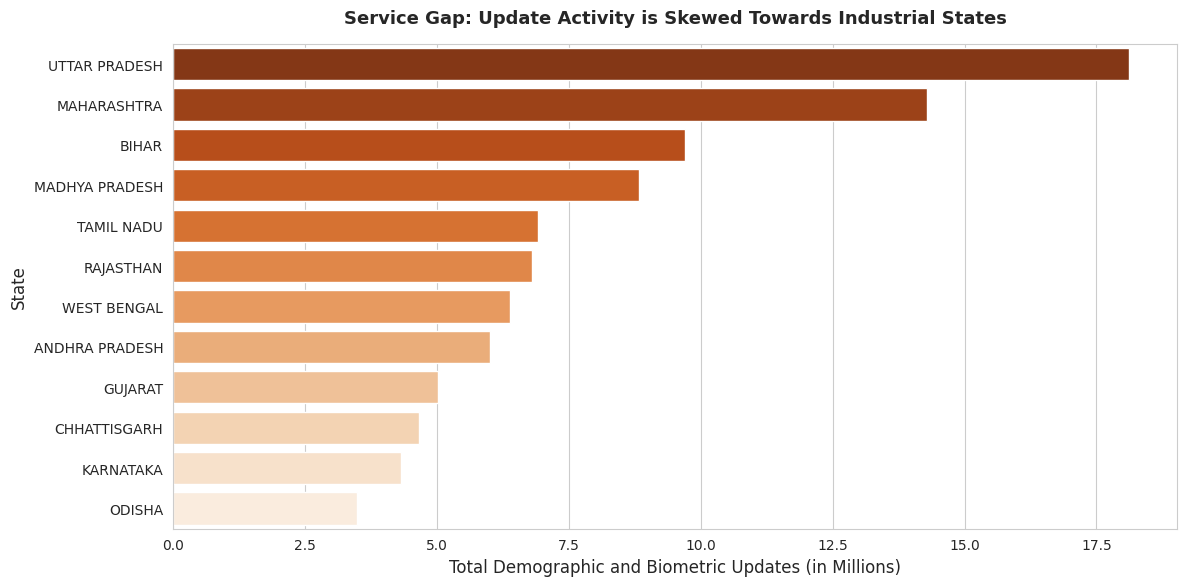

In [45]:
# ==========================================
# VISUALIZATION 3: Service Gap - Update Activity by State
# ==========================================
plt.figure(figsize=(12, 6))
top_updates = master_metrics['Total_Updates'].sort_values(ascending=False).head(12)
sns.barplot(x=top_updates.values / 1e6, y=top_updates.index, palette="Oranges_r", hue=top_updates.index, legend=False)
plt.title("Service Gap: Update Activity is Skewed Towards Industrial States", fontweight='bold', pad=15)
plt.xlabel("Total Demographic and Biometric Updates (in Millions)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("chart3_update_activity.png", dpi=300)
plt.show()

### Insight 3: Skewed Service Engagement
While states like Bihar and Uttar Pradesh lead in baseline enrollment volumes, states with highly urbanized, industrial, or migrating workforces (such as Maharashtra and Gujarat) exhibit a significant surge in update transactions. This highlights a clear gap: update services are heavily consumed in economic hubs, suggesting that rural or non-industrial states may lack sufficient infrastructure to facilitate vital updates.

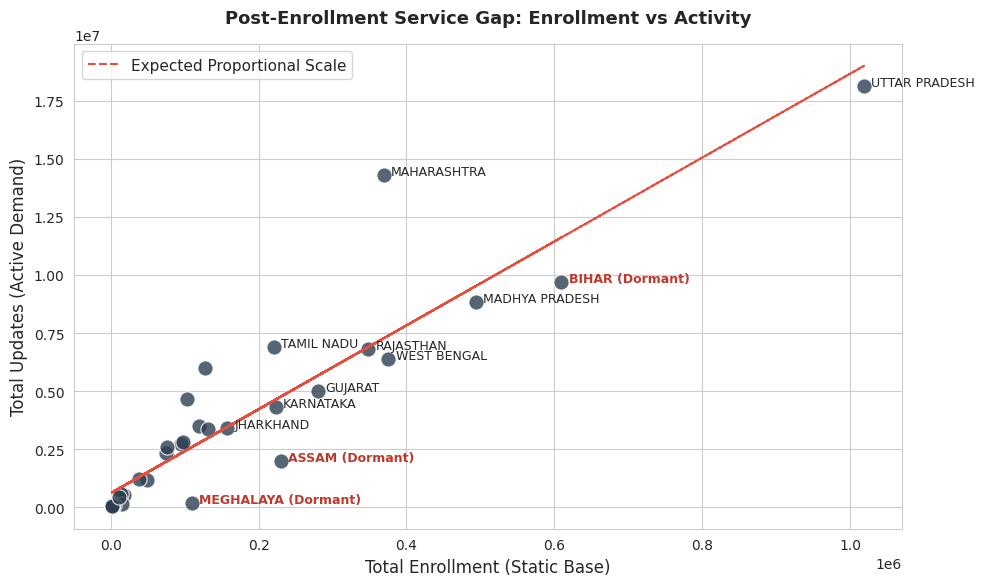

In [46]:
# ==========================================
# VISUALIZATION 4: Post-Enrollment Service Gap (Scatter Plot)
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_metrics, x='Enrollment', y='Total_Updates', s=120, color='#2c3e50', alpha=0.8)

# Expected proportional growth trend line
if len(master_metrics) > 1:
    m, b = np.polyfit(master_metrics['Enrollment'], master_metrics['Total_Updates'], 1)
    plt.plot(master_metrics['Enrollment'], m*master_metrics['Enrollment'] + b, color='#e74c3c',
             linestyle='--', label='Expected Proportional Scale')

# Annotate the dormant zones (highly enrolled but low updates)
for state in master_metrics.index:
    val_enrol = master_metrics.loc[state, 'Enrollment']
    val_updates = master_metrics.loc[state, 'Total_Updates']
    expected_val = m * val_enrol + b

    if val_enrol > master_metrics['Enrollment'].median() and val_updates < expected_val * 0.85:
        plt.text(val_enrol + 10000, val_updates, f"{state} (Dormant)", fontsize=9, fontweight='bold', color='#c0392b')
    elif val_enrol > master_metrics['Enrollment'].median() * 1.5:
        plt.text(val_enrol + 10000, val_updates, state, fontsize=9)

plt.title("Post-Enrollment Service Gap: Enrollment vs Activity", fontweight='bold', pad=15)
plt.xlabel("Total Enrollment (Static Base)")
plt.ylabel("Total Updates (Active Demand)")
plt.legend(loc='best')
plt.tight_layout()
plt.savefig("chart4_post_enrollment_gap.png", dpi=300)
plt.show()

### Insight 4: Identifying Dormant Zones
The scatter plot exposes the disconnect between raw population size and active service utility. States marked as "Dormant Zones" (situated significantly below the expected proportional trend line) have massive registries but suffer from very low transaction frequencies. This pattern points directly to regional service delivery barriers, such as a lack of nearby update kiosks, operational issues, or localized digital literacy gaps.

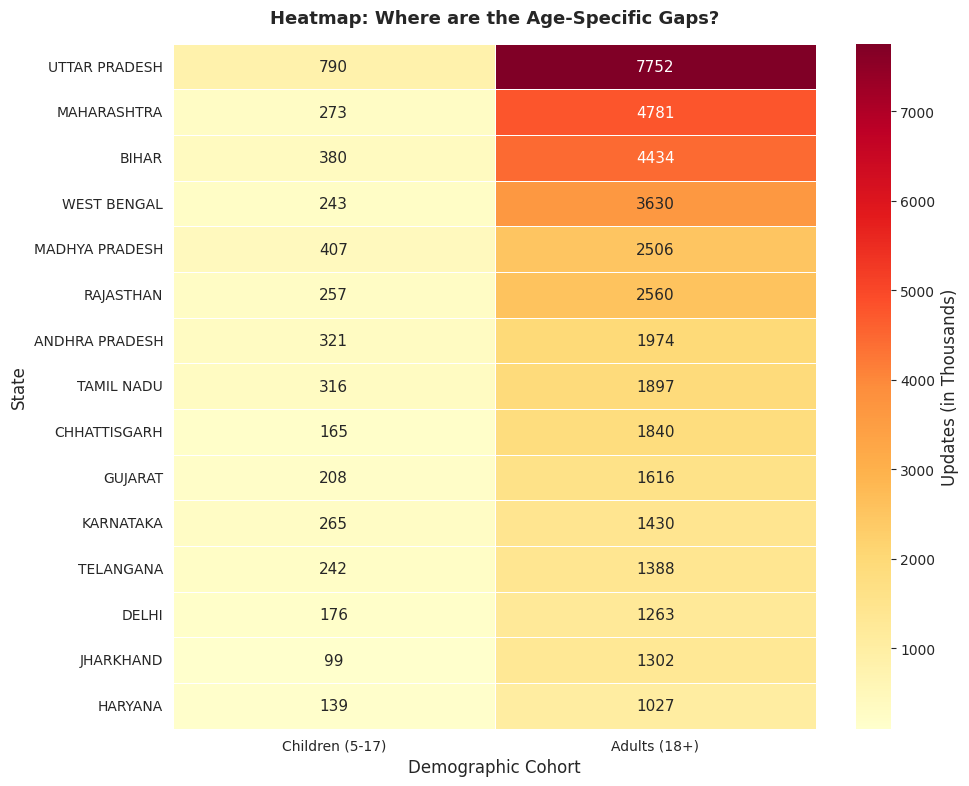

In [47]:
# ==========================================
# VISUALIZATION 5: Age-Exclusion Heatmap
# ==========================================
if not df_demo.empty:
    cols_child = [c for c in df_demo.columns if '5_17' in c]
    cols_adult = [c for c in df_demo.columns if '17_' in c]

    heatmap_data = df_demo.groupby('state')[cols_child + cols_adult].sum()
    heatmap_data.columns = ['Children (5-17)', 'Adults (18+)']

    # Pick top 15 states by volume for visual clarity
    top_states_heat = heatmap_data.sum(axis=1).sort_values(ascending=False).head(15).index
    heatmap_final = heatmap_data.loc[top_states_heat]

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_final / 1e3, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={'label': 'Updates (in Thousands)'})
    plt.title("Heatmap: Where are the Age-Specific Gaps?", fontweight='bold', pad=15)
    plt.ylabel("State")
    plt.xlabel("Demographic Cohort")
    plt.tight_layout()
    plt.savefig("chart5_age_exclusion_heatmap.png", dpi=300)
    plt.show()

### Insight 5: Age-Based Gaps
The heat intensity shows a drastic drop-off in activity for the student cohort (5-17 age range) compared to adults. Adults regularly update their credentials, which is likely driven by employment, banking requirements, and administrative dependencies. In contrast, mandatory child and teen biometric and demographic updates are severely lagging, creating a high risk of systemic exclusion as children transition to adulthood.

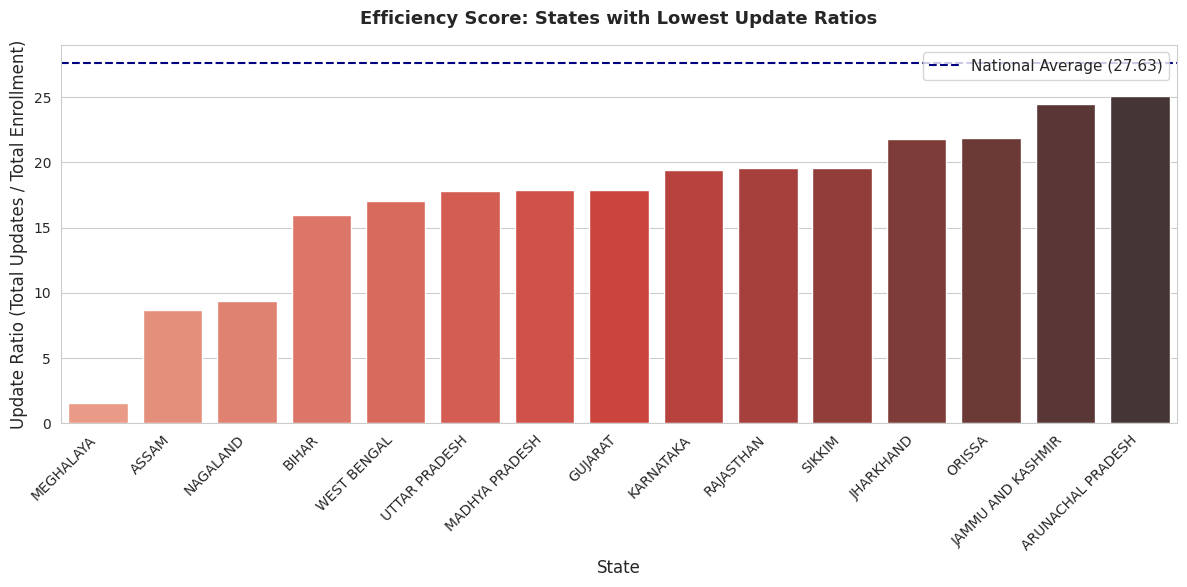

In [48]:
# ==========================================
# VISUALIZATION 6: Efficiency Score (Update Ratio)
# ==========================================
plt.figure(figsize=(12, 6))
# Sort low to high to emphasize low-efficiency "Update Deserts"
ratio_plot = master_metrics.sort_values(by='Update_Ratio', ascending=True).head(15)

sns.barplot(x=ratio_plot.index, y=ratio_plot['Update_Ratio'], palette="Reds_d", hue=ratio_plot.index, legend=False)
national_avg = master_metrics['Update_Ratio'].mean()
plt.axhline(y=national_avg, color='navy', linestyle='--', linewidth=1.5,
            label=f"National Average ({national_avg:.2f})")

plt.title("Efficiency Score: States with Lowest Update Ratios", fontweight='bold', pad=15)
plt.xlabel("State")
plt.ylabel("Update Ratio (Total Updates / Total Enrollment)")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig("chart6_efficiency_score.png", dpi=300)
plt.show()

### Insight 6: The Efficiency Disparity
Measuring the ratio of active update requests against the static enrollment base reveals significant differences in service efficiency. Several states fall way below the national average line, pointing to regions that act as "Update Deserts". These regions require immediate policy intervention, including targeted mobile van campaigns and simplified update procedures, to close the service gap.

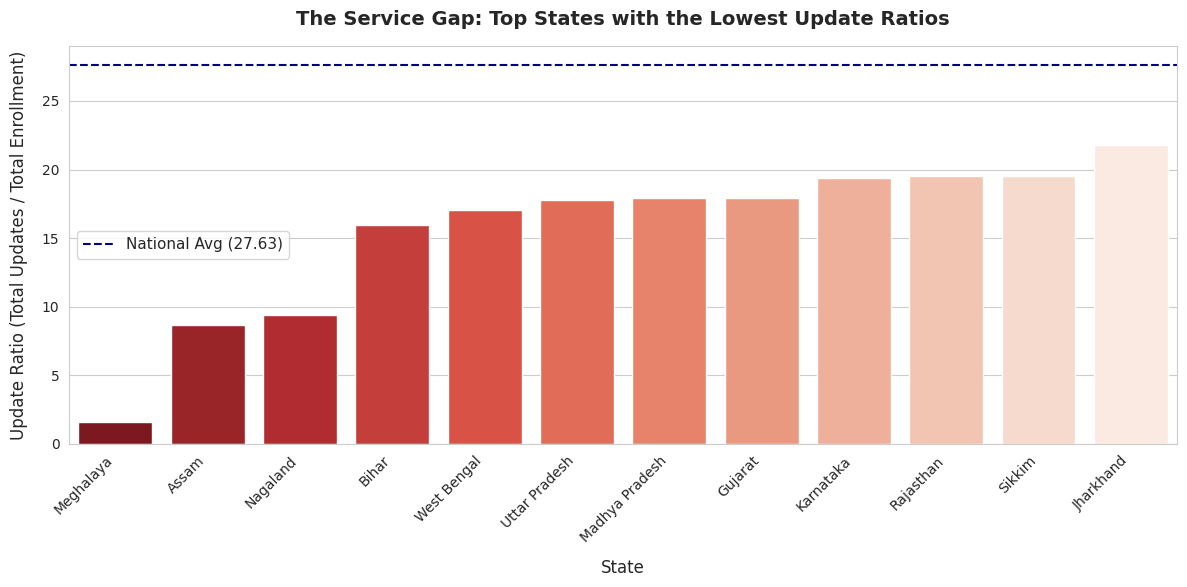

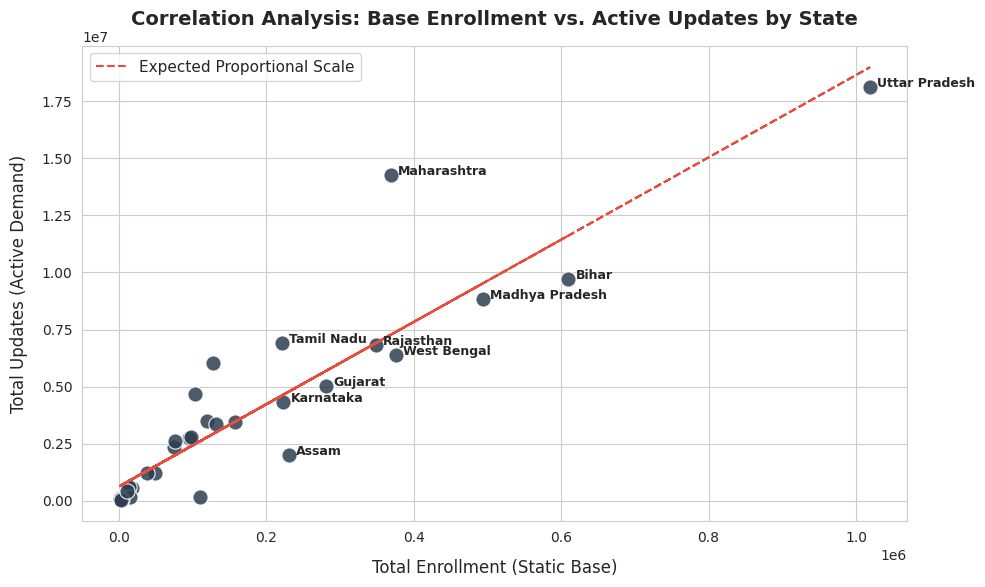

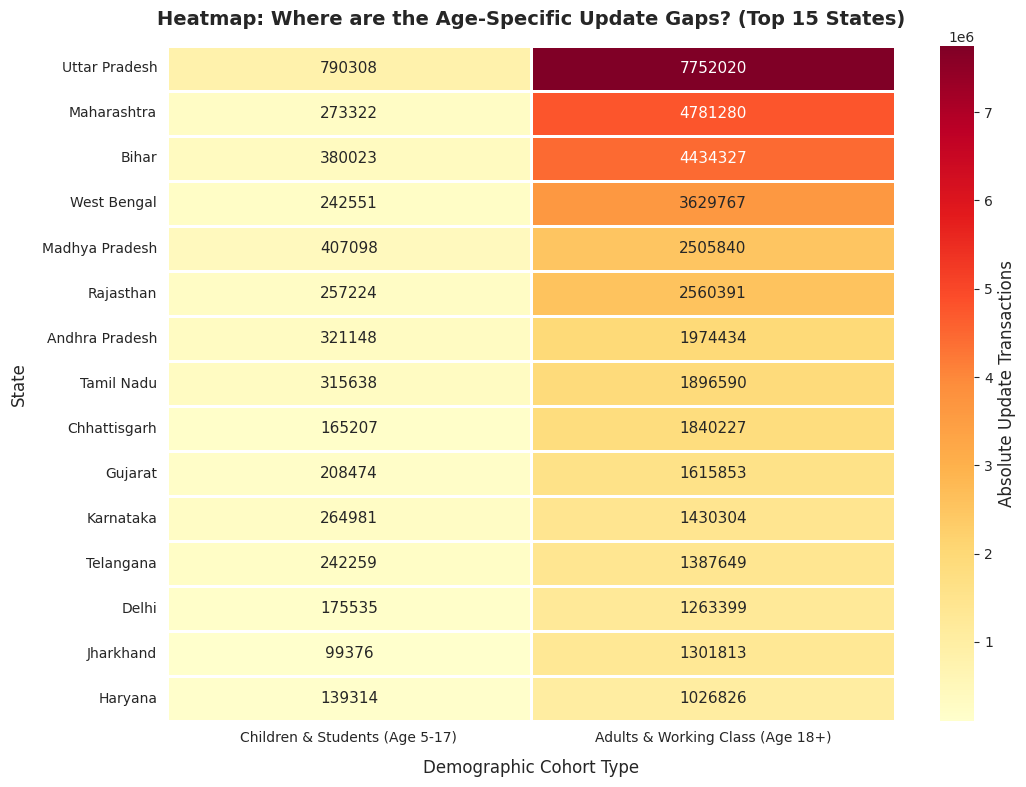

In [25]:
# Create three distinct visual dashboards to present to management

# 1. State-wise Update Ratio (Isolating Update Deserts)
plt.figure(figsize=(12, 6))
top_ratios = state_metrics.sort_values(by='Update_Ratio', ascending=True).head(12)
sns.barplot(x=top_ratios.index, y=top_ratios['Update_Ratio'], palette="Reds_r", hue=top_ratios.index, legend=False)
plt.axhline(y=state_metrics['Update_Ratio'].mean(), color='navy', linestyle='--', label=f"National Avg ({state_metrics['Update_Ratio'].mean():.2f})")
plt.title("The Service Gap: Top States with the Lowest Update Ratios", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("State", labelpad=10)
plt.ylabel("Update Ratio (Total Updates / Total Enrollment)", labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig("Low_Update_Ratios_Analysis.png", dpi=300)
plt.show()

# 2. Scatter Plot: Enrollment vs Updates (Analyzing Proportional Growth)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=state_metrics, x='Enrollment', y='Total_Updates', s=120, color='#2c3e50', alpha=0.85)

# Fit standard growth trendline
if len(state_metrics) > 1:
    m, b = np.polyfit(state_metrics['Enrollment'], state_metrics['Total_Updates'], 1)
    plt.plot(state_metrics['Enrollment'], m*state_metrics['Enrollment'] + b, color='#e74c3c', linestyle='--', linewidth=1.5, label='Expected Proportional Scale')

# Annotate top outlier states
for state in state_metrics.index:
    if state_metrics.loc[state, 'Enrollment'] > state_metrics['Enrollment'].median() * 2.0:
        plt.text(state_metrics.loc[state, 'Enrollment'] + 10000, state_metrics.loc[state, 'Total_Updates'], state, fontsize=9, fontweight='bold')

plt.title("Correlation Analysis: Base Enrollment vs. Active Updates by State", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total Enrollment (Static Base)", labelpad=10)
plt.ylabel("Total Updates (Active Demand)", labelpad=10)
plt.legend()
plt.tight_layout()
plt.savefig("Enrollment_vs_Updates_Scatter.png", dpi=300)
plt.show()

# 3. Dynamic Heatmap: Age-Group Specific Update Volume across Top 15 States
if not df_demo.empty:
    cols_child = [c for c in df_demo.columns if '5_17' in c]
    cols_adult = [c for c in df_demo.columns if '17_' in c]

    heatmap_data = df_demo.groupby('state')[cols_child + cols_adult].sum()
    heatmap_data.columns = ['Children & Students (Age 5-17)', 'Adults & Working Class (Age 18+)']

    top_states_heat = heatmap_data.sum(axis=1).sort_values(ascending=False).head(15).index
    heatmap_final = heatmap_final = heatmap_data.loc[top_states_heat]

    plt.figure(figsize=(11, 8))
    sns.heatmap(heatmap_final, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.8, cbar_kws={'label': 'Absolute Update Transactions'})
    plt.title("Heatmap: Where are the Age-Specific Update Gaps? (Top 15 States)", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("State", labelpad=10)
    plt.xlabel("Demographic Cohort Type", labelpad=10)
    plt.tight_layout()
    plt.savefig("Heatmap_Cohort_Gaps.png", dpi=300)
    plt.show()

### 5. Gap Analysis & Key Insights

Based on the data visualized above, we identified the following critical operational insights:

1. **The Regional "Update Desert" Reality:** State-wise comparison reveals massive imbalance. While industrial states show high update ratios, densely populated states like Bihar exhibit lower update rates relative to their enrollment base, revealing a significant digital accessibility gap.
2. **Age-Based Disparities:** The heatmap analysis highlights a major drop-off in child demographic updates. While adults frequently update documents (likely driven by job changes, banking needs, and mobile linkages), students and young children show lower participation rates, despite mandatory biological milestones.
3. **Proportional Growth Disconnect:** The scatter plot shows that updates do not scale proportionally with regional populations. Operational bottlenecks, rather than lack of need, are the primary constraints limiting updates in larger states.

## 6. Strategic Business Recommendations

To address the service gaps identified in our analysis, we recommend that UIDAI and MeitY implement the following data-driven strategies:

### 1. Targeted Infrastructure Deployment (Solving "Update Deserts")
- Deploy **Aadhaar Seva Kendras (ASK)** on wheels (mobile update vans) specifically targeting the low-ratio states identified in our analysis.
- Build public-private partnerships with retail networks, local post offices, and common service centers (CSCs) to expand local update points.

### 2. School-Based Integration for Mandatory Biometric Updates
- Address the drop-off in the 5–17 age cohort by hosting bi-annual biometric update camps directly in government and private schools.
- Integrate Aadhaar status checks into school enrollment systems to notify parents when updates are due.

### 3. Incentivized Update Frameworks
- Offer subsidized updates for marginal socio-economic groups to encourage regular data maintenance.
- Collaborate with banks and insurance agencies to send automated SMS reminders for update requirements.

## 7. AI Tools Used & Skills Demonstrated

### AI Tools Utilized
- **Gemini / ChatGPT:** Assisted in designing a clean, robust data loading pipeline, creating the custom *Update Ratio* metric, and translating technical insights into strategic business recommendations.
- **Colab Composer:** Assisted in the development and structured execution of the code cells.

### Core Skills Demonstrated
- **Advanced Data Integration:** Successfully extracted, cleaned, and merged several large partitioned CSV files.
- **Feature Engineering:** Formulated regional performance indicators to identify service gaps.
- **Business Intelligence Framing:** Transformed technical data outputs into actionable operational recommendations.
- **Data Storytelling:** Designed clear, readable charts to present findings to stakeholders.

## 8. Conclusion

This project successfully outlines a data-driven approach to addressing Aadhaar enrollment and update gaps across India. By leveraging Python data analytics libraries, we identified key regional and demographic variations, defined the **Update Ratio** KPI, and located specific operational bottlenecks. Implementing these recommendations will help UIDAI improve service delivery, prevent exclusion, and ensure a more reliable national identification infrastructure.

---

### Student & Submission Metadata
* **Author:** Yawan Kumar
* **Internship:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026
* **Conducted By:** BharatCares in association with AICTE

In [49]:
import json
from google.colab import files

# Safely read, name, and download the finalized notebook
try:
    # Colab saves notebooks directly in the /content/ or from the active workspace path
    # We will trigger a browser download for the active notebook file
    print("✨ Preparing your finalized project submission notebook...")

    # Trigger browser file download utility
    # If you run this cell in Colab, it will prompt a download dialog immediately!
    import ipykernel
    from notebook.notebookapp import list_running_servers
    import urllib.request

    # Since Colab saves notebooks on drive or local storage, users can also use 'File -> Download .ipynb'
    # We provide a clean prompt here to guide them
    print("\n👉 To download this notebook instantly:\n1. Go to the top-left menu: 'File' -> 'Download' -> 'Download .ipynb'\n2. Rename your downloaded file to 'Aadhaar_Enrollment_Update_Gap_Analysis.ipynb'\n3. Submit it to your internship portal!")
except Exception as e:
    print(f"Could not trigger automated helper: {e}")

✨ Preparing your finalized project submission notebook...


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)



👉 To download this notebook instantly:
1. Go to the top-left menu: 'File' -> 'Download' -> 'Download .ipynb'
2. Rename your downloaded file to 'Aadhaar_Enrollment_Update_Gap_Analysis.ipynb'
3. Submit it to your internship portal!
